<a href="https://colab.research.google.com/github/tshrayansh/BEE-workshop-IMSc/blob/main/BEE_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

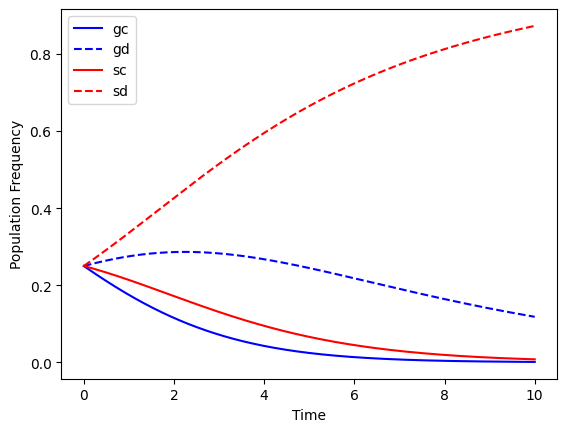

In [ ]:
from matplotlib.lines import lineStyles
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
fs = 1.2
fg = 1
#f = fitness

b = 1 #benifit
c = 0.5 #cost of cooperation
a = 0.1 #cost of conjugation

def system(x,t):
  global fg,fs,b,c,a
  #x=[gc,gd,sc,sd]
  f = fg*(x[0]+x[1]) + fs*(x[2]+x[3])

  gc = (fg - f)*x[0] + a*(x[0]*x[1]) - c*x[0] + b*x[0]*(c*x[0]+c*x[2])

  gd = (fg - f)*x[1] - a*(x[0]*x[1]) + b*x[1]*(c*x[0]+c*x[2])
  sc = (fs - f)*x[2] + a*(x[0]*x[3]) - c*x[2] + b*x[2]*(c*x[0]+c*x[2])
  sd = (fs - f)*x[3] - a*(x[0]*x[3]) + b*x[3]*(c*x[0]+c*x[2])

  x = [gc,gd,sc,sd]
  return x

t = np.linspace(0,10,100000)
x0 = [0.25,0.25,0.25,0.25]

x = odeint(system,x0,t)

plt.plot(t,x[:,0],label='gc',color='blue')
plt.plot(t,x[:,1],label='gd',color='blue',linestyle='dashed')
plt.plot(t,x[:,2],label='sc',color='red')
plt.plot(t,x[:,3],label='sd',color='red',linestyle='dashed')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Population Frequency')
plt.show()

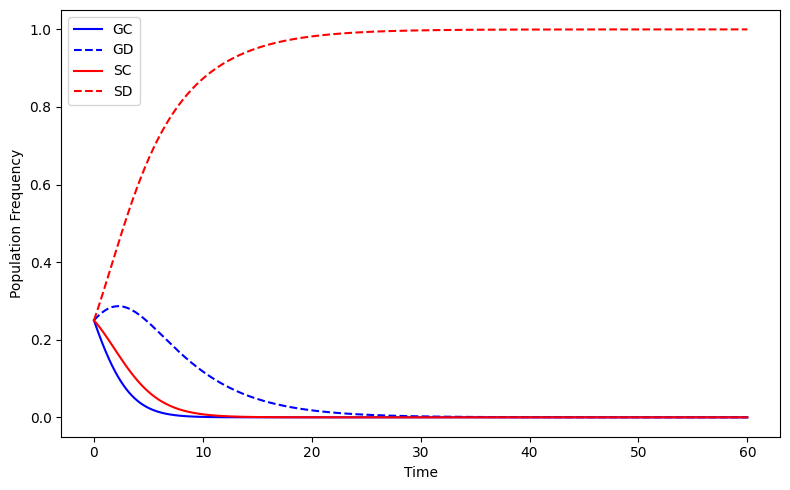

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Base fitness
fg = 1.0      # generous
fs = 1.2      # secretive

# Parameters
b = 1.0       # benefit from public good
c = 0.5       # cost of cooperation
alpha = 0.1   # conjugation rate


def system(x, t):

    GC, GD, SC, SD = x

    # Public good pool
    P = GC + SC

    # Individual fitnesses
    F_GC = fg - c + b * P
    F_GD = fg + b * P

    F_SC = fs - c + b * P
    F_SD = fs + b * P

    # Mean fitness
    F_bar = (
        F_GC * GC +
        F_GD * GD +
        F_SC * SC +
        F_SD * SD
    )

    # Replicator + conjugation dynamics

    dGC = (F_GC - F_bar) * GC + alpha * GC * GD

    dGD = (F_GD - F_bar) * GD - alpha * GC * GD

    dSC = (F_SC - F_bar) * SC + alpha * GC * SD

    dSD = (F_SD - F_bar) * SD - alpha * GC * SD

    return [dGC, dGD, dSC, dSD]


# Initial condition
x0 = [0.25, 0.25, 0.25, 0.25]

# Time
t = np.linspace(0, 60, 100000)

# Solve
x = odeint(system, x0, t)

# Plot
plt.figure(figsize=(8,5))

plt.plot(t, x[:,0], label='GC', color='blue')
plt.plot(t, x[:,1], label='GD', color='blue', linestyle='--')

plt.plot(t, x[:,2], label='SC', color='red')
plt.plot(t, x[:,3], label='SD', color='red', linestyle='--')

plt.xlabel('Time')
plt.ylabel('Population Frequency')
plt.legend()
plt.tight_layout()
plt.show()